In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [2]:
DATA_PATH = '../dataset/YoutubeCommentsDataSet.csv'

df = pd.read_csv(DATA_PATH)

df.head()

,Comment,Sentiment
0,lets not forget that apple pay in 2014 require...,neutral
1,here in nz 50 of retailers don’t even have con...,negative
2,i will forever acknowledge this channel with t...,positive
3,whenever i go to a place that doesn’t take app...,negative
4,apple pay is so convenient secure and easy to ...,positive


In [3]:
print(df.shape)

df.info()

(18408, 2)
<class 'pandas.DataFrame'>
RangeIndex: 18408 entries, 0 to 18407
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Comment    18364 non-null  str  
 1   Sentiment  18408 non-null  str  
dtypes: str(2)
memory usage: 3.6 MB


In [4]:
df.isnull().sum()

Comment      44
Sentiment     0
dtype: int64

In [5]:
df.dropna(inplace=True)

In [6]:
print("Duplicate:", df.duplicated().sum())

Duplicate: 490


In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df["Sentiment"].value_counts()

Sentiment
positive    11054
neutral      4503
negative     2317
Name: count, dtype: int64

In [9]:
(df["Sentiment"].value_counts(normalize=True)*100)

Sentiment
positive    61.844019
neutral     25.193018
negative    12.962963
Name: proportion, dtype: float64

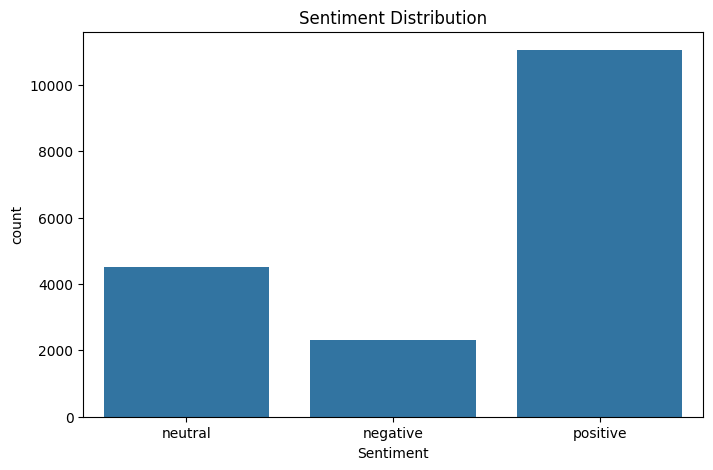

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Sentiment",
    data=df
)

plt.title("Sentiment Distribution")
plt.show()

In [11]:
df["comment_length"] = df["Comment"].apply(len)

df["comment_length"].describe()

count    17874.000000
mean       177.705214
std        252.135479
min          2.000000
25%         66.000000
50%        113.000000
75%        201.000000
max       7847.000000
Name: comment_length, dtype: float64

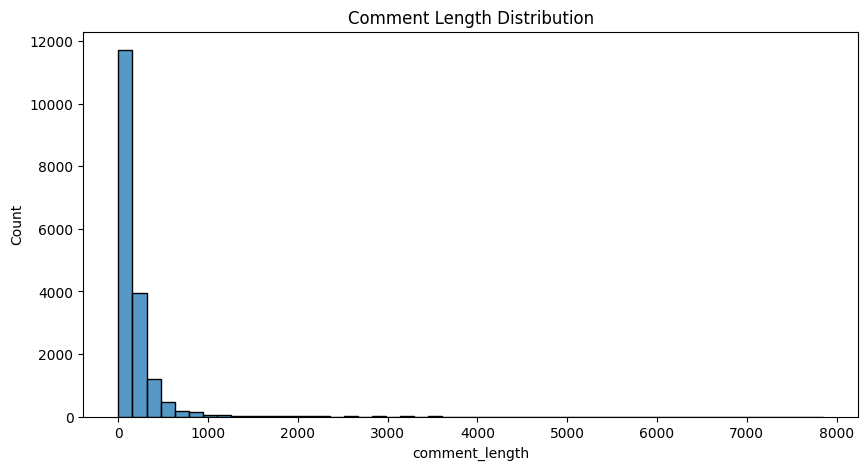

In [12]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["comment_length"],
    bins=50
)

plt.title("Comment Length Distribution")
plt.show()

In [13]:
df.groupby("Sentiment")["comment_length"].mean()

Sentiment
negative    210.874407
neutral     195.100378
positive    163.666546
Name: comment_length, dtype: float64

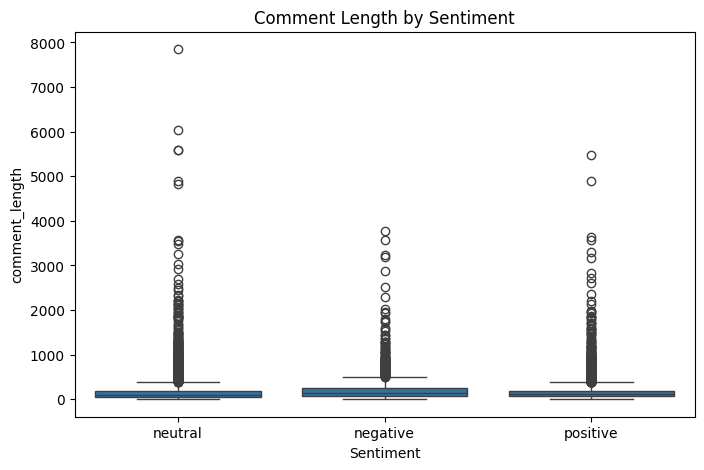

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Sentiment",
    y="comment_length",
    data=df
)

plt.title("Comment Length by Sentiment")
plt.show()

In [15]:
df.to_csv(
    "../dataset/youtube_clean.csv",
    index=False
)